# Load modules

In [109]:
import os
import xarray as xr
import pyproj
import numpy as np
from glob import glob 
from tqdm import tqdm
from datetime import datetime

import matplotlib.pyplot as plt 
from scipy import stats
import cartopy.crs as ccrs
import cmocean 
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import MaxNLocator, FixedLocator, FixedFormatter

import functions

# Define directories

In [84]:
path_current = os.getcwd()
path_data = os.path.join(path_current, 'Fields_INALT60/')

main_path = '/Users/solangecoadou/Desktop/Desktop/Thesis/'
swot_dir= main_path+'GRL_2026_SWOT_SQG/DATA/Swot_fast_sampling/'

path_save_data = os.path.join(path_current, 'SWOT_analysis/Fast_sampling/')

path_DUACS= main_path+'Data_QUICCHE/DUACS_new/'

# Grid eSQG model

In [117]:
bathy = xr.open_dataset(path_data+'bathy_INALT60.nc')

lon_c=15.7
lat_c=-37.8

pos_west,pos_east,pos_south,pos_north  = lon_c-2,lon_c+2,lat_c-2,lat_c+2

bathy_region=bathy.where((bathy.nav_lat>pos_south-1.2) & (bathy.nav_lat<pos_north+1.2) & (bathy.nav_lon>pos_west-1.2) & (bathy.nav_lon<pos_east+1.2), drop=True)

dx=2
lon_grid=bathy_region.nav_lon
lat_grid=bathy_region.nav_lat

#Define the grid
a = pyproj.Transformer.from_crs(4326,3395).transform(lon_grid,lat_grid) # project WGS84 onto metric grid
y3 = a[0]
x3 = a[1]
x3min = np.nanmin(x3,1)
y3min = np.nanmin(y3,0)
Y3min,X3min = np.meshgrid(y3min, x3min)
x1=(x3-X3min)/1000
y1=(y3-Y3min)/1000
x_len = int(np.floor(np.amax(x1))+1)
y_len = int(np.floor(np.amax(y1))+1)
x_dim = np.linspace(0, x_len, int(x_len/dx), endpoint=False)
y_dim = np.linspace(0, y_len, int(y_len/dx), endpoint=False)
x2, y2 = np.meshgrid(x_dim, y_dim)
    
#Add nav_lon and nav_lat back from the interpolation 
x2_proj = x2*1000 + x3min[0]
y2_proj = y2*1000 + y3min[0]
transformer_back = pyproj.Transformer.from_crs(3395, 4326, always_xy=True)
lat2, lon2 = transformer_back.transform(y2_proj,x2_proj)

#Make square
size_x=len(lon2[0,:])
size_y=len(lon2[:,0])

if size_y>size_x:
    delta_points=size_y-size_x
    lon2 = lon2[:size_x,:]
    lat2 = lat2[:size_x,:]
else:
    delta_points=size_x-size_y
    lon2 = lon2[:,:size_y]
    lat2 = lat2[:,:size_y]
    
lonBIG, latBIG = lon2, lat2
latmin, latmax = np.min(lat2), np.max(lat2)
lonmin, lonmax = np.min(lon2), np.max(lon2)

lon2, lat2 = lon2[50:-50,50:-50], lat2[50:-50,50:-50]
latminbox, latmaxbox = np.min(lat2), np.max(lat2)
lonminbox, lonmaxbox = np.min(lon2), np.max(lon2)

# Read data

In [118]:
start = datetime(2023, 3, 29)
stop = datetime(2023, 7, 10) 

#DUACS
filenames = [x for x in glob(path_DUACS+'*.nc')] 
filenames.sort()
ds_ssh = xr.open_mfdataset(filenames).sel(time=slice(np.datetime64(start),np.datetime64(stop)), latitude=slice(latmin,latmax), longitude=slice(lonmin,lonmax))

# Compute RMS time series of vertical velocity

In [76]:
makeLOWVAR=0
makeHIGHVAR=1

if makeHIGHVAR:
    folder='high_var/'
    pos_west,pos_east,pos_south,pos_north  = 16,17.75,-39.5,-38.15 #Define box (about 150km)
elif makeLOWVAR:
    folder='low_var/'
    pos_west,pos_east,pos_south,pos_north  = 15.15,16.85,-37,-35.65

cycle=np.arange(474,578)
depth_list = np.array([4.7679895e-01, 1.5707064e+00, 2.8554180e+00, 4.3355064e+00,
       6.0156703e+00, 7.9007444e+00, 9.9957113e+00, 1.2305715e+01,
       1.4836073e+01, 1.7592300e+01, 2.0580124e+01, 2.3805506e+01,
       2.7274673e+01, 3.0994144e+01, 3.4970764e+01, 3.9211739e+01,
       4.3724689e+01, 4.8517693e+01, 5.3599339e+01, 5.8978794e+01,
       6.4665886e+01, 7.0671165e+01, 7.7006004e+01, 8.3682709e+01,
       9.0714615e+01, 9.8116249e+01, 1.0590342e+02, 1.1409344e+02,
       1.2270523e+02, 1.3175960e+02, 1.4127936e+02, 1.5128963e+02,
       1.6181805e+02, 1.7289508e+02, 1.8455423e+02, 1.9683240e+02,
       2.0977017e+02, 2.2341211e+02, 2.3780708e+02, 2.5300858e+02,
       2.6907489e+02, 2.8606949e+02, 3.0406100e+02, 3.2312344e+02,
       3.4333621e+02, 3.6478378e+02, 3.8755551e+02, 4.1174518e+02,
       4.3745007e+02, 4.6477032e+02, 4.9380743e+02, 5.2466309e+02,
       5.5743713e+02, 5.9222620e+02, 6.2912128e+02, 6.6820563e+02,
       7.0955292e+02, 7.5322528e+02, 7.9927124e+02, 8.4772443e+02,
       8.9860266e+02, 9.5190729e+02], dtype=np.float32)

RMS_vorticity = np.zeros(len(depth_list))+np.nan
RMS_velocity = np.zeros(len(depth_list))+np.nan

for c in tqdm(cycle):
    file_SWOT_pot_up = [x for x in glob(swot_dir+'*_'+str(c)+'_001_*.nc')]
    file_SWOT_pot_down = [x for x in glob(swot_dir+'*_'+str(c)+'_016_*.nc')]
    file_combine = np.concatenate((file_SWOT_pot_up, file_SWOT_pot_down))
    if len(file_combine)>0:
        for ff in range(len(file_combine)):
            field='vorticity'
            zeta_sqg, mask_zeta, lon_zeta, lat_zeta = compute_sqg_swot(depth_list, file_combine[ff], field)
            field='velocity'
            w_sqg, mask_w, lon_w, lat_w = compute_sqg_swot(depth_list, file_combine[ff], field)
            if ff==0:
                if len(lon_zeta)>1:
                    field_masked = zeta_sqg
                    field_masked[:,mask_zeta]=np.nan
                    id_removed = np.concatenate((np.arange(0,4),[24], [32], np.arange(54,57)))
                    field_masked[:,:,id_removed]=np.nan
                    id_select_row, id_select_col = np.where((lon_zeta>pos_west) & (lon_zeta<pos_east) & (lat_zeta>pos_south) & (lat_zeta<pos_north))
                    zeta_flat = field_masked[:,id_select_row, id_select_col]
                    
                    field_masked = w_sqg
                    field_masked[:,mask_w]=np.nan
                    field_masked[:,:,id_removed]=np.nan
                    id_select_row, id_select_col = np.where((lon_w>pos_west) & (lon_w<pos_east) & (lat_w>pos_south) & (lat_w<pos_north))
                    w_flat = field_masked[:,id_select_row, id_select_col]

                    zeta_combine = zeta_flat
                    w_combine = w_flat
                else:
                    zeta_combine = np.ones([len(depth_list),1])+np.nan
                    w_combine = np.ones([len(depth_list),1])+np.nan
                    
            else:
                if len(lon_zeta)>1:
                    field_masked = zeta_sqg
                    field_masked[:,mask_zeta]=np.nan
                    id_removed = np.concatenate((np.arange(0,4),[24], [32], np.arange(54,57)))
                    field_masked[:,:,id_removed]=np.nan
                    id_select_row, id_select_col = np.where((lon_zeta>pos_west) & (lon_zeta<pos_east) & (lat_zeta>pos_south) & (lat_zeta<pos_north))
                    zeta_flat = field_masked[:,id_select_row, id_select_col]
                    
                    field_masked = w_sqg
                    field_masked[:,mask_w]=np.nan
                    field_masked[:,:,id_removed]=np.nan
                    id_select_row, id_select_col = np.where((lon_w>pos_west) & (lon_w<pos_east) & (lat_w>pos_south) & (lat_w<pos_north))
                    w_flat = field_masked[:,id_select_row, id_select_col]

                    zeta_combine = np.concatenate((zeta_combine,zeta_flat), axis=1)
                    w_combine = np.concatenate((w_combine,w_flat), axis=1)
                else:
                    zeta_nan = np.ones([len(depth_list),1])+np.nan
                    w_nan = np.ones([len(depth_list),1])+np.nan
                    zeta_combine = np.concatenate((zeta_combine,zeta_nan), axis=1)
                    w_combine = np.concatenate((w_combine,w_nan), axis=1)
                    
        RMS_vorticity=np.sqrt(np.nanmean((zeta_combine**2),axis=1))
        RMS_velocity=np.sqrt(np.nanmean((w_combine**2),axis=1))

        ds_to_save = xr.Dataset(
                    data_vars=dict(
                        RMS_vorticity=(["z"], RMS_vorticity),
                        RMS_velocity=(["z"], RMS_velocity)
    
                    ),
                    coords=dict(
                        z=("z", depth_list),
                        cycle=("cycle", np.array([c]))
                    ) 
                )
        path_folder = os.path.join(path_save_data, folder)
        os.makedirs(path_folder, exist_ok=True)
        ds_to_save.to_netcdf(path=path_folder+str(c)+'.nc')

  0%|                                                                                                                                                                               | 0/104 [00:00<?, ?it/s]

k = 0
k = 1
k = 2
k = 3
k = 4
k = 5
k = 6
k = 7
k = 8
k = 9
k = 10
k = 11
k = 12
k = 13
k = 14
k = 15
k = 16
k = 17
k = 18
k = 19
k = 20
k = 21
k = 22
k = 23
k = 24
k = 25
k = 26
k = 27
k = 28
k = 29
k = 30
k = 31
k = 32
k = 33
k = 34
k = 35
k = 36
k = 37
k = 38
k = 39
k = 40
k = 41
k = 42
k = 43
k = 44
k = 45
k = 46
k = 47
k = 48
k = 49
k = 50
k = 51
k = 52
k = 53
k = 54
k = 55
k = 56
k = 57
k = 58
k = 59
k = 60
k = 61


  1%|█▌                                                                                                                                                                     | 1/104 [00:03<05:56,  3.46s/it]

k = 0
k = 1
k = 2
k = 3
k = 4
k = 5
k = 6
k = 7
k = 8
k = 9
k = 10
k = 11
k = 12
k = 13
k = 14
k = 15
k = 16
k = 17
k = 18
k = 19
k = 20
k = 21
k = 22
k = 23
k = 24
k = 25
k = 26
k = 27
k = 28
k = 29
k = 30
k = 31
k = 32
k = 33
k = 34
k = 35
k = 36
k = 37
k = 38
k = 39
k = 40
k = 41
k = 42
k = 43
k = 44
k = 45
k = 46
k = 47
k = 48
k = 49
k = 50
k = 51
k = 52
k = 53
k = 54
k = 55
k = 56
k = 57
k = 58
k = 59
k = 60
k = 61


/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/100030110.py:86: RuntimeWarning: Mean of empty slice
  RMS_vorticity=np.sqrt(np.nanmean((zeta_combine**2),axis=1))
/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/100030110.py:87: RuntimeWarning: Mean of empty slice
  RMS_velocity=np.sqrt(np.nanmean((w_combine**2),axis=1))
  2%|███▏                                                                                                                                                                   | 2/104 [00:06<05:25,  3.19s/it]

...

 98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊   | 102/104 [09:26<00:11,  5.54s/it]

k = 0
k = 1
k = 2
k = 3
k = 4
k = 5
k = 6
k = 7
k = 8
k = 9
k = 10
k = 11
k = 12
k = 13
k = 14
k = 15
k = 16
k = 17
k = 18
k = 19
k = 20
k = 21
k = 22
k = 23
k = 24
k = 25
k = 26
k = 27
k = 28
k = 29
k = 30
k = 31
k = 32
k = 33
k = 34
k = 35
k = 36
k = 37
k = 38
k = 39
k = 40
k = 41
k = 42
k = 43
k = 44
k = 45
k = 46
k = 47
k = 48
k = 49
k = 50
k = 51
k = 52
k = 53
k = 54
k = 55
k = 56
k = 57
k = 58
k = 59
k = 60
k = 61
k = 0
k = 1
k = 2
k = 3
k = 4
k = 5
k = 6
k = 7
k = 8
k = 9
k = 10
k = 11
k = 12
k = 13
k = 14
k = 15
k = 16
k = 17
k = 18
k = 19
k = 20
k = 21
k = 22
k = 23
k = 24
k = 25
k = 26
k = 27
k = 28
k = 29
k = 30
k = 31
k = 32
k = 33
k = 34
k = 35
k = 36
k = 37
k = 38
k = 39
k = 40
k = 41
k = 42
k = 43
k = 44
k = 45
k = 46
k = 47
k = 48
k = 49
k = 50
k = 51
k = 52
k = 53
k = 54
k = 55
k = 56
k = 57
k = 58
k = 59
k = 60
k = 61


 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍ | 103/104 [09:32<00:05,  5.68s/it]

k = 0
k = 1
k = 2
k = 3
k = 4
k = 5
k = 6
k = 7
k = 8
k = 9
k = 10
k = 11
k = 12
k = 13
k = 14
k = 15
k = 16
k = 17
k = 18
k = 19
k = 20
k = 21
k = 22
k = 23
k = 24
k = 25
k = 26
k = 27
k = 28
k = 29
k = 30
k = 31
k = 32
k = 33
k = 34
k = 35
k = 36
k = 37
k = 38
k = 39
k = 40
k = 41
k = 42
k = 43
k = 44
k = 45
k = 46
k = 47
k = 48
k = 49
k = 50
k = 51
k = 52
k = 53
k = 54
k = 55
k = 56
k = 57
k = 58
k = 59
k = 60
k = 61
k = 0
k = 1
k = 2
k = 3
k = 4
k = 5
k = 6
k = 7
k = 8
k = 9
k = 10
k = 11
k = 12
k = 13
k = 14
k = 15
k = 16
k = 17
k = 18
k = 19
k = 20
k = 21
k = 22
k = 23
k = 24
k = 25
k = 26
k = 27
k = 28
k = 29
k = 30
k = 31
k = 32
k = 33
k = 34
k = 35
k = 36
k = 37
k = 38
k = 39
k = 40
k = 41
k = 42
k = 43
k = 44
k = 45
k = 46
k = 47
k = 48
k = 49
k = 50
k = 51
k = 52
k = 53
k = 54
k = 55
k = 56
k = 57
k = 58
k = 59
k = 60
k = 61


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 104/104 [09:38<00:00,  5.56s/it]


# Compute RMS time series of surface strain and vorticity

In [69]:
makeLOWVAR=0
makeHIGHVAR=1
cycle=np.arange(474,578)
depth_list = np.array([0], dtype=np.float32)

if makeHIGHVAR:
    folder='high_var/'
    pos_west,pos_east,pos_south,pos_north  = 16,17.75,-39.5,-38.15     #Define box (about 150km)
    RMS_vorticity_high = np.zeros(len(cycle))+np.nan
    RMS_strain_high = np.zeros(len(cycle))+np.nan
elif makeLOWVAR:
    folder='low_var/'
    pos_west,pos_east,pos_south,pos_north  = 15.15,16.85,-37,-35.65
    RMS_vorticity_low = np.zeros(len(cycle))+np.nan
    RMS_strain_low = np.zeros(len(cycle))+np.nan


for c, ic in zip(cycle, np.arange(len(cycle))):
    file_SWOT_pot_up = [x for x in glob(swot_dir+'*_'+str(c)+'_001_*.nc')]
    file_SWOT_pot_down = [x for x in glob(swot_dir+'*_'+str(c)+'_016_*.nc')]
    file_combine = np.concatenate((file_SWOT_pot_up, file_SWOT_pot_down))
    if len(file_combine)>0:
        for ff in range(len(file_combine)):
            field='vorticity'
            zeta_sqg, mask_zeta, lon_zeta, lat_zeta = compute_sqg_swot(depth_list, file_combine[ff], field)
            field='strain'
            w_sqg, mask_w, lon_w, lat_w = compute_sqg_swot(depth_list, file_combine[ff], field)
            if ff==0:
                if len(lon_zeta)>1:
                    field_masked = zeta_sqg
                    field_masked[mask_zeta]=np.nan
                    id_removed = np.concatenate((np.arange(0,4),[24], [32], np.arange(54,57)))
                    field_masked[:,id_removed]=np.nan
                    id_select_row, id_select_col = np.where((lon_zeta>pos_west) & (lon_zeta<pos_east) & (lat_zeta>pos_south) & (lat_zeta<pos_north))
                    zeta_flat = field_masked[id_select_row, id_select_col]
                    
                    field_masked = w_sqg
                    field_masked[mask_w]=np.nan
                    field_masked[:,id_removed]=np.nan
                    id_select_row, id_select_col = np.where((lon_w>pos_west) & (lon_w<pos_east) & (lat_w>pos_south) & (lat_w<pos_north))
                    w_flat = field_masked[id_select_row, id_select_col]

                    zeta_combine = zeta_flat
                    w_combine = w_flat
                else:
                    zeta_combine = np.ones(1)+np.nan
                    w_combine = np.ones(1)+np.nan
                    
            else:
                if len(lon_zeta)>1:
                    field_masked = zeta_sqg
                    field_masked[mask_zeta]=np.nan
                    id_removed = np.concatenate((np.arange(0,4),[24], [32], np.arange(54,57)))
                    field_masked[:,id_removed]=np.nan
                    id_select_row, id_select_col = np.where((lon_zeta>pos_west) & (lon_zeta<pos_east) & (lat_zeta>pos_south) & (lat_zeta<pos_north))
                    zeta_flat = field_masked[id_select_row, id_select_col]
                    
                    field_masked = w_sqg
                    field_masked[mask_w]=np.nan
                    field_masked[:,id_removed]=np.nan
                    id_select_row, id_select_col = np.where((lon_w>pos_west) & (lon_w<pos_east) & (lat_w>pos_south) & (lat_w<pos_north))
                    w_flat = field_masked[id_select_row, id_select_col]

                    zeta_combine = np.concatenate((zeta_combine,zeta_flat))
                    w_combine = np.concatenate((w_combine,w_flat))
                else:
                    zeta_nan = np.ones(1)+np.nan
                    w_nan = np.ones(1)+np.nan
                    zeta_combine = np.concatenate((zeta_combine,zeta_nan))
                    w_combine = np.concatenate((w_combine,w_nan))
                    
        if makeHIGHVAR:
            RMS_vorticity_high[ic]=np.sqrt(np.nanmean((zeta_combine**2)))
            RMS_strain_high[ic]=np.sqrt(np.nanmean((w_combine**2)))
        elif makeLOWVAR:
            RMS_vorticity_low[ic]=np.sqrt(np.nanmean((zeta_combine**2)))
            RMS_strain_low[ic]=np.sqrt(np.nanmean((w_combine**2)))

k = 0
k = 0
k = 0
k = 0


/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/3674819174.py:73: RuntimeWarning: Mean of empty slice
  RMS_vorticity_high[ic]=np.sqrt(np.nanmean((zeta_combine**2)))
/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/3674819174.py:74: RuntimeWarning: Mean of empty slice
  RMS_strain_high[ic]=np.sqrt(np.nanmean((w_combine**2)))


k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0


/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/3674819174.py:73: RuntimeWarning: Mean of empty slice
  RMS_vorticity_high[ic]=np.sqrt(np.nanmean((zeta_combine**2)))
/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/3674819174.py:74: RuntimeWarning: Mean of empty slice
  RMS_strain_high[ic]=np.sqrt(np.nanmean((w_combine**2)))


k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 

/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/3674819174.py:73: RuntimeWarning: Mean of empty slice
  RMS_vorticity_high[ic]=np.sqrt(np.nanmean((zeta_combine**2)))
/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/3674819174.py:74: RuntimeWarning: Mean of empty slice
  RMS_strain_high[ic]=np.sqrt(np.nanmean((w_combine**2)))


k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0


/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/3674819174.py:73: RuntimeWarning: Mean of empty slice
  RMS_vorticity_high[ic]=np.sqrt(np.nanmean((zeta_combine**2)))
/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/3674819174.py:74: RuntimeWarning: Mean of empty slice
  RMS_strain_high[ic]=np.sqrt(np.nanmean((w_combine**2)))


k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0
k = 0


# Compute DUACS eSQG fields

In [116]:
ds_ssh.longitude

<xarray.DataArray 'longitude' (longitude: 36)>
array([13.4375, 13.5625, 13.6875, 13.8125, 13.9375, 14.0625, 14.1875, 14.3125,
       14.4375, 14.5625, 14.6875, 14.8125, 14.9375, 15.0625, 15.1875, 15.3125,
       15.4375, 15.5625, 15.6875, 15.8125, 15.9375, 16.0625, 16.1875, 16.3125,
       16.4375, 16.5625, 16.6875, 16.8125, 16.9375, 17.0625, 17.1875, 17.3125,
       17.4375, 17.5625, 17.6875, 17.8125], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 13.44 13.56 13.69 13.81 ... 17.56 17.69 17.81
Attributes:
    axis:           X
    long_name:      Longitude
    standard_name:  longitude
    units:          degrees_east
    valid_max:      179.9375
    valid_min:      -179.9375
    bounds:         lon_bnds

In [125]:
#Parameter
depth=4.1174518e+02
day1 = 6
day2 = 70
dx = 2 # Grid spacing in km
    #Filtering
cutoff_lenght = 40
hws=int(2*(cutoff_lenght/dx)-1)
cutoff_frequency = 1/(cutoff_lenght/dx)

    #eSQG
N02 = 3.4e-6
N0=np.sqrt(N02)
cc=2
g = 9.81
rho0=1.e+3
Rho0oN02og=rho0/N02/g
goN02orho0=g/N02/rho0

#Define the grid - interpolate on a regular metric grid
lon_grid,lat_grid = np.meshgrid(ds_ssh.longitude,ds_ssh.latitude)
a = pyproj.Transformer.from_crs(4326,3395).transform(lon_grid,lat_grid) # project WGS84 onto metric grid
y3 = a[0]
x3 = a[1]
x3min = np.nanmin(x3,1)
y3min = np.nanmin(y3,0)
Y3min,X3min = np.meshgrid(y3min, x3min)
x1=(x3-X3min)/1000
y1=(y3-Y3min)/1000
x_len = int(np.floor(np.amax(x1))+1)
y_len = int(np.floor(np.amax(y1))+1)
x_dim = np.linspace(0, x_len, int(x_len/dx), endpoint=False)
y_dim = np.linspace(0, y_len, int(y_len/dx), endpoint=False)
x2, y2 = np.meshgrid(x_dim, y_dim)

#Add nav_lon and nav_lat back from the interpolation 
x2_proj = x2*1000 + x3min[0]
y2_proj = y2*1000 + y3min[0]
transformer_back = pyproj.Transformer.from_crs(3395, 4326, always_xy=True)
lat2, lon2 = transformer_back.transform(y2_proj,x2_proj)
lat2, lon2 = lat2[:345,:], lon2[:345,:]

#Other param eSQG
f0 = abs(np.mean(f(lat2.flatten())))
N0of0=N0/f0
gof0=g/f0
rho_cst=N0of0*rho0

#Day1
ssh_gridded = xr.apply_ufunc(interp_to_grid,
                 ds_ssh.adt.isel(time=day1), x1, y1, x2, y2,
                 input_core_dims=[["latitude","longitude"], ["latitude","longitude"], ["latitude","longitude"], ["new_y","new_x"], ["new_y","new_x"]],
                 output_core_dims=[["new_y","new_x"]],
                 exclude_dims=set(("latitude","longitude")),
                 vectorize = True,
                 dask="parallelized",
                 output_dtypes=[ds_ssh.adt.dtype]).rename({"new_y": "latitude", "new_x": "longitude"}).compute().isel(latitude=slice(0,345))

#Filtering

#lon = ssh_gridded.longitude.data
#lat = ssh_gridded.latitude.data

field_filter_ref = filter_convolution2d(LanczosKernel(cutoff_frequency, hws),ssh_gridded.data)

#Compute w
ssh_det2 = ssh_preprocessing_sqg(field_filter_ref)
M=len(ssh_det2[:,0])
L=len(ssh_det2[0,:])
kx,ky,kkx,kky,kk = get_kxky(L,M,2000,2000)
zz = np.array([-depth])*N0of0
N=len(zz)

zeta_duacs_first_day = -np.squeeze(sqg_rel_vort(ssh_det2, M, L, N, kk, zz, gof0))/f0
w_duacs_first_day = np.squeeze(sqg_w(ssh_det2, cc, rho_cst, M, L, N, kk, kkx, kky, zz, goN02orho0, gof0))

ssh_gridded = xr.apply_ufunc(interp_to_grid,
                 ds_ssh.adt.isel(time=day2), x1, y1, x2, y2,
                 input_core_dims=[["latitude","longitude"], ["latitude","longitude"], ["latitude","longitude"], ["new_y","new_x"], ["new_y","new_x"]],
                 output_core_dims=[["new_y","new_x"]],
                 exclude_dims=set(("latitude","longitude")),
                 vectorize = True,
                 dask="parallelized",
                 output_dtypes=[ds_ssh.adt.dtype]).rename({"new_y": "latitude", "new_x": "longitude"}).compute().isel(latitude=slice(0,345))

field_filter_ref = filter_convolution2d(LanczosKernel(cutoff_frequency, hws),ssh_gridded.data)

#Compute W
ssh_det2 = ssh_preprocessing_sqg(field_filter_ref)

zeta_duacs_2nd_day = -np.squeeze(sqg_rel_vort(ssh_det2, M, L, N, kk, zz, gof0))/f0
w_duacs_2nd_day = np.squeeze(sqg_w(ssh_det2, cc, rho_cst, M, L, N, kk, kkx, kky, zz, goN02orho0, gof0))

data: (51, 49)
k = 0
data: (51, 49)
k = 0


# Plot figure

/var/folders/gb/7q2cybx53vsb8lvgk2rgvjqm0000gn/T/ipykernel_65713/3417314203.py:72: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.xaxis.set_major_formatter(x_formatter)


k = 0
k = 0
k = 0
k = 0


Text(13.2, -35.9, '7/06')

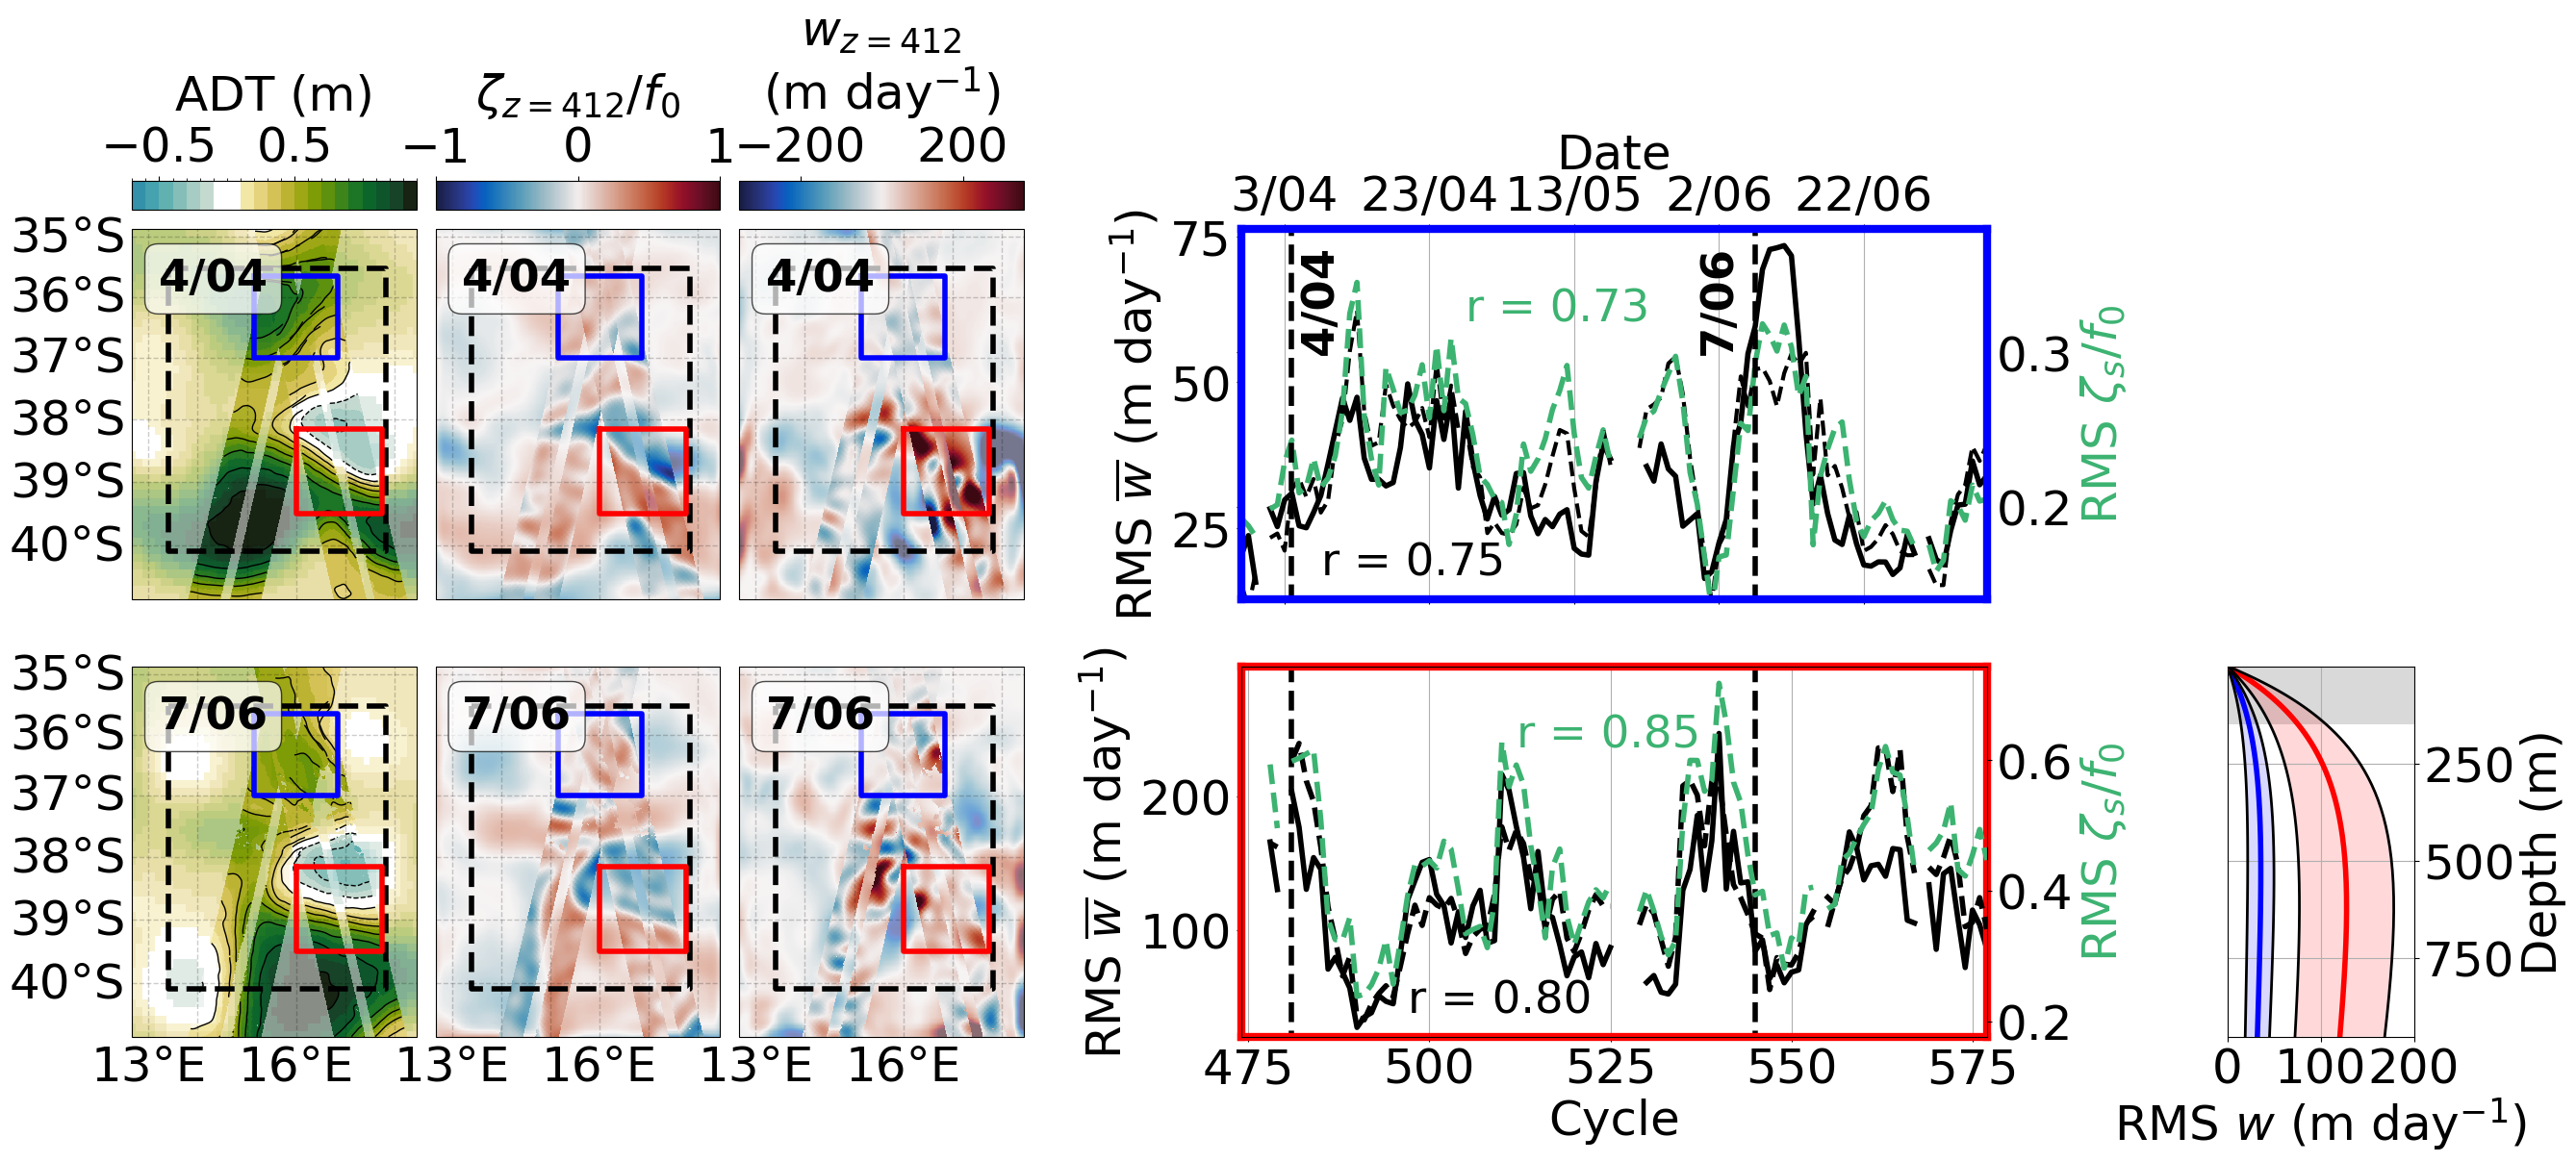

In [128]:
#Parameters
props = dict(boxstyle='round', facecolor='w', alpha=0.7)
depth_level= np.array([4.1174518e+02], dtype=np.float32)
ft=36
    #Maps
latmin, latmax = np.min(lat2[6:-6, 6:-6]), np.max(lat2[6:-6, 6:-6])
lonmin, lonmax = np.min(lon2[6:-6, 6:-6]), np.max(lon2[6:-6, 6:-6])
pos_west,pos_east,pos_south,pos_north  = lonmin,lonmax,latmin,latmax  #Reset the area
proj = ccrs.Mercator(central_longitude=(pos_west+pos_east)/2,min_latitude=pos_south,max_latitude=pos_north)
crs = ccrs.PlateCarree()
extent=[pos_west, pos_east, pos_south, pos_north]
cartmap = proj,crs,extent
    #Colorbar ADT
Tinc=np.arange(-0.7,1.5, 0.1)
cmap1 = cmocean.tools.crop(cmocean.cm.delta, vmin=Tinc[0], vmax=Tinc[-1], pivot=0)
newcolors = cmap1(np.linspace(0, 1, len(Tinc)))
pos = np.where(Tinc>=0)[0][0]
white = np.array([1, 1, 1, 1])
newcolors[pos-2:pos, :] = white
cmap = ListedColormap(newcolors)
levels = MaxNLocator(nbins=len(Tinc)).tick_values(Tinc[0], Tinc[-1])
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True) 

fig = plt.figure(figsize=(10,5))

#Plot timeseries - low variability region
folder = 'low_var/'
RMS_files = [x for x in glob(swot_dir+folder+'*.nc')]
ds_rms = xr.open_mfdataset(RMS_files)
ymin, ymax = ds_rms.z.isel(z=0), ds_rms.z.isel(z=-1)
data = ds_rms.RMS_velocity
mean_profile = data.mean(dim='cycle').compute()
env_5 = mean_profile-data.std(dim=['cycle']).compute()
env_95 = mean_profile+data.std(dim=['cycle']).compute()

    #RMS w
rms_w = data.isel(z=slice(36,54)).mean(dim='z')
id_cut = np.where(np.diff(rms_w.cycle.values)>1)[0]
plt.plot(data.cycle[:3], rms_w[:3], 'k',linewidth=4, label='$w$')
plt.plot(data.cycle[3:51], rms_w[3:51], 'k',linewidth=4)
plt.plot(data.cycle[52:], rms_w[52:], 'k',linewidth=4)

plt.gca().tick_params(axis='both',labelsize=ft)
plt.gca().set_ylabel('RMS $\overline{w}$ (m day$^{-1}$)',fontsize=ft)


plt.gca().xaxis.grid(True)
corr = stats.pearsonr(RMS_strain_low[np.where(np.isnan(RMS_strain_low)==0)[0]], rms_w.values[np.where(np.isnan(rms_w)==0)[0]])[0]
plt.text(485,17, 'r = ' + str(np.round(corr*100)/100), fontsize=ft-2.5)

    #RMS strain and vorticity
ax=plt.gca()
ax1=plt.gca().twinx()
ax1.plot(cycle, RMS_strain_low, 'k--',linewidth=3, label='$\sigma_s/f_0$')
ax1.plot(cycle, RMS_vorticity_low, 'mediumseagreen', linestyle='--',linewidth=4, label='$\zeta_s/f_0$')
corr = stats.pearsonr(RMS_vorticity_low[np.where(np.isnan(RMS_vorticity_low)==0)[0]], rms_w.values[np.where(np.isnan(rms_w)==0)[0]])[0]
ax1.text(505,0.32, 'r = ' + str(np.round(corr*100)/100), color = 'mediumseagreen', fontsize=ft-2.5)

ax1.set_xlim(data.cycle[0], data.cycle[-1]) 
ax1.set_xlabel('Cycle',fontsize=ft)
ax1.set_ylabel('RMS $\zeta_s/f_0$',fontsize=ft, color='mediumseagreen')
ax1.tick_params(axis='both',labelsize=ft)
for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(6)
    ax1.spines[axis].set_color('b')

ax1.tick_params(bottom=True, top=True, left=True, right=False)

datedisp = np.array([480, 500, 520, 540, 560])
x_formatter = FixedFormatter(['3/04', '23/04', '13/05', '2/06', '22/06'])
x_locator = FixedLocator(datedisp)
ax.xaxis.set_major_formatter(x_formatter)
ax.xaxis.set_major_locator(x_locator)
ax.tick_params(axis='x', which='both', top=True, labeltop=True) 
ax.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
ax.set_xlabel('Date', fontsize=ft)
ax.xaxis.set_label_position('top') 

#Plot RMS vertical profiles mean + envelop
pos1=ax1.get_position()
ax1bis=fig.add_axes([pos1.x0+pos1.width+.25, pos1.y0-pos1.height-0.14, pos1.width/4, pos1.height])
ax1bis.plot(mean_profile, data.z, 'b', linewidth=4)
ax1bis.plot(env_5, data.z, 'k', linewidth=2)
ax1bis.plot(env_95, data.z, 'k', linewidth=2)

    #Fill in between envelop
x = np.concatenate((env_5, np.flip(env_95), [env_5[0]]))
y = np.concatenate((data.z, np.flip(data.z), [data.z.isel(z=0)]))
ax1bis.fill(x,y,'b', alpha=.15)
ax1bis.tick_params(axis='y', which='both', right=True, labelright=True) 
ax1bis.tick_params(axis='y', which='both', left=False, labelleft=False)
ax1bis.set_ylabel('Depth (m)', fontsize=ft)
ax1bis.yaxis.set_label_position('right') 
ax1bis.tick_params(axis='both',labelsize=ft)
ax1bis.fill([0,300,300,0,0],[150, 150, 0, 0, 150],'k', alpha=.15)
ax1bis.set_ylim(ymin, ymax) 
ax1bis.set_xlim(0, 200)
ax1bis.set_xticks(np.arange(0,210, 100))
ax1bis.invert_yaxis()
ax1bis.set_xlabel('RMS $w$ (m day$^{-1}$)',fontsize=ft, labelpad=2)
plt.grid()


#Plot timeseries - high variability region
folder = 'high_var/'
RMS_files = [x for x in glob(swot_dir+folder+'*.nc')]
ds_rms = xr.open_mfdataset(RMS_files)
vmin, vmax = 10, 340
data = ds_rms.RMS_velocity
mean_profile = data.mean(dim='cycle').compute()
env_5 = mean_profile-data.std(dim=['cycle']).compute()
env_95 = mean_profile+data.std(dim=['cycle']).compute()
ax2=fig.add_axes([pos1.x0, pos1.y0-pos1.height-0.14, pos1.width, pos1.height])
    #RMS w
rms_w = data.isel(z=slice(36,54)).mean(dim='z')
ax2.plot(data.cycle[:3], rms_w[:3], 'k',linewidth=4, label='$\overline{w}$')
ax2.plot(data.cycle[3:51], rms_w[3:51], 'k',linewidth=4)
ax2.plot(data.cycle[52:], rms_w[52:], 'k',linewidth=4)
ax2.set_ylabel('RMS $\overline{w}$ (m day$^{-1}$)',fontsize=ft)
plt.gca().xaxis.grid(True)
corr = stats.pearsonr(RMS_strain_high[np.where(np.isnan(RMS_strain_high)==0)[0]], rms_w.values[np.where(np.isnan(rms_w)==0)[0]])[0]
ax2.text(497,38, 'r = ' + str(np.round(corr*100)/100)+'0', fontsize=ft-2.5)
ax2.tick_params(axis='both',labelsize=ft)

    #RMS strain and vorticity
ax2bis=ax2.twinx()
ax2bis.plot(cycle, RMS_strain_high, 'k--',linewidth=4, label='$\sigma_s/f_0$')
ax2bis.plot(cycle, RMS_vorticity_high, 'mediumseagreen', linestyle='--',linewidth=4, label='$\zeta_s/f_0$')
corr = stats.pearsonr(RMS_vorticity_high[np.where(np.isnan(RMS_vorticity_high)==0)[0]], rms_w.values[np.where(np.isnan(rms_w)==0)[0]])[0]
ax2bis.text(512,0.62, 'r = ' + str(np.round(corr*100)/100), color = 'mediumseagreen', fontsize=ft-2.5)
ax2.set_xlim(data.cycle[0], data.cycle[-1]) 
ax2.set_xlabel('Cycle',fontsize=ft)
ax2bis.set_ylabel('RMS $\zeta_s/f_0$',fontsize=ft, color='mediumseagreen')
ax2bis.tick_params(axis='both',labelsize=ft)

for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(6)
    ax2.spines[axis].set_color('r')

    #Plot RMS vertical profiles mean + envelop
ax1bis.plot(mean_profile, data.z, 'r', linewidth=4)
ax1bis.plot(env_5, data.z, 'k', linewidth=2)
ax1bis.plot(env_95, data.z, 'k', linewidth=2)
#Fill in between envelop
x = np.concatenate((env_5, np.flip(env_95), [env_5[0]]))
y = np.concatenate((data.z, np.flip(data.z), [data.z.isel(z=0)]))
ax1bis.fill(x,y,'r', alpha=.15)

#Add maps

ax01 = fig.add_axes([pos1.x0-pos1.width*.5-.18,pos1.y0, pos1.width*.5, pos1.height], projection=proj)
ax01.set_extent(extent)
map_grid=ax01.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=False,zorder=6)

pos01=ax01.get_position()
pos2=ax2.get_position()
ax02 = fig.add_axes([pos2.x0-pos2.width*.5-.18,pos2.y0, pos2.width*.5, pos2.height], projection=proj)
ax02.set_extent(extent)
map_grid=ax02.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
map_grid.top_labels = False
map_grid.right_labels = False
map_grid.left_labels = False
map_grid.bottom_labels = True

map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft}

ax03 = fig.add_axes([pos01.x0-pos01.width-.02,pos01.y0, pos01.width, pos01.height], projection=proj)
ax03.set_extent(extent)
map_grid=ax03.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=False,zorder=6)

pos02=ax02.get_position()
ax04 = fig.add_axes([pos02.x0-pos02.width-.02,pos02.y0, pos02.width, pos02.height], projection=proj)
ax04.set_extent(extent)
map_grid=ax04.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
map_grid.top_labels = False
map_grid.right_labels = False
map_grid.left_labels = False
map_grid.bottom_labels = True

map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft}

pos03=ax03.get_position()
ax05 = fig.add_axes([pos03.x0-pos03.width-.02,pos03.y0, pos03.width, pos03.height], projection=proj)
ax05.set_extent(extent)
map_grid=ax05.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=False,zorder=6)
map_grid.top_labels = False
map_grid.right_labels = False
map_grid.left_labels = True
map_grid.bottom_labels = False

map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft}

pos04=ax04.get_position()
ax06 = fig.add_axes([pos04.x0-pos04.width-.02,pos04.y0, pos04.width, pos04.height], projection=proj)
ax06.set_extent(extent)
map_grid=ax06.gridlines(linewidth=1, color='black', alpha=0.2, linestyle='--', draw_labels=True,zorder=6)
map_grid.top_labels = False
map_grid.right_labels = False
map_grid.left_labels = True
map_grid.bottom_labels = True

map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft}

    #Add DUACS
ax03.pcolormesh(lon2[6:-6, 6:-6], lat2[6:-6, 6:-6], zeta_duacs_first_day[6:-6, 6:-6], cmap=cmocean.cm.balance, vmin=-.7, vmax=.7, transform=crs, alpha=.6)
ax04.pcolormesh(lon2[6:-6, 6:-6], lat2[6:-6, 6:-6], zeta_duacs_2nd_day[6:-6, 6:-6], cmap=cmocean.cm.balance, vmin=-.7, vmax=.7, transform=crs, alpha=.6)

ax01.pcolormesh(lon2[6:-6, 6:-6], lat2[6:-6, 6:-6], w_duacs_first_day[6:-6, 6:-6], cmap=cmocean.cm.balance, vmin=-100, vmax=100, transform=crs, alpha=.6)
ax02.pcolormesh(lon2[6:-6, 6:-6], lat2[6:-6, 6:-6], w_duacs_2nd_day[6:-6, 6:-6], cmap=cmocean.cm.balance, vmin=-100, vmax=100, transform=crs, alpha=.6)

    #Add SWOT vorticity and w - first day
c=481
file_SWOT_pot_up = [x for x in glob(swot_dir+'*_'+str(c)+'_001_*.nc')]
file_SWOT_pot_down = [x for x in glob(swot_dir+'*_'+str(c)+'_016_*.nc')]
file_combine = np.concatenate((file_SWOT_pot_up, file_SWOT_pot_down))
if len(file_combine)>0:
    for ff in range(len(file_combine)):
        field='vorticity'
        zeta_sqg, mask_zeta, lon_zeta, lat_zeta = compute_sqg_swot(depth_level, file_combine[ff], field)
        field='velocity'
        w_sqg, mask_w, lon_w, lat_w = compute_sqg_swot(depth_level, file_combine[ff], field)

        field_masked = zeta_sqg
        field_masked[mask_zeta]=np.nan
        id_removed = np.concatenate((np.arange(0,4),[24], [32], np.arange(54,57)))
        field_masked[:,id_removed]=np.nan
        
        #Plot zeta:
        ax03.pcolormesh(lon_zeta, lat_zeta, -field_masked, cmap=cmocean.cm.balance, vmin=-1, vmax=1, transform=crs)

        #Plot w
        field_masked = w_sqg
        field_masked[mask_w]=np.nan
        id_removed = np.concatenate((np.arange(0,4),[24], [32], np.arange(54,57)))
        field_masked[:,id_removed]=np.nan
        
        #Plot w:
        ax01.pcolormesh(lon_w, lat_w, field_masked, cmap=cmocean.cm.balance, vmin=-350, vmax=350, transform=crs)

    #Add SWOT vorticity and w - second day
c=545
file_SWOT_pot_up = [x for x in glob(swot_dir+'*_'+str(c)+'_001_*.nc')]
file_SWOT_pot_down = [x for x in glob(swot_dir+'*_'+str(c)+'_016_*.nc')]
file_combine = np.concatenate((file_SWOT_pot_up, file_SWOT_pot_down))
if len(file_combine)>0:
    for ff in range(len(file_combine)):
        field='vorticity'
        zeta_sqg, mask_zeta, lon_zeta, lat_zeta = compute_sqg_swot(depth_level, file_combine[ff], field)
        field='velocity'
        w_sqg, mask_w, lon_w, lat_w = compute_sqg_swot(depth_level, file_combine[ff], field)

        field_masked = zeta_sqg
        field_masked[mask_zeta]=np.nan
        id_removed = np.concatenate((np.arange(0,4),[24], [32], np.arange(54,57)))
        field_masked[:,id_removed]=np.nan
        
        #Plot zeta:
        im1 = ax04.pcolormesh(lon_zeta, lat_zeta, -field_masked, cmap=cmocean.cm.balance, vmin=-1, vmax=1, transform=crs)

        #Plot w
        field_masked = w_sqg
        field_masked[mask_w]=np.nan
        id_removed = np.concatenate((np.arange(0,4),[24], [32], np.arange(54,57)))
        field_masked[:,id_removed]=np.nan
        
        #Plot w:
        im2 = ax02.pcolormesh(lon_w, lat_w, field_masked, cmap=cmocean.cm.balance, vmin=-350, vmax=350, transform=crs)
        if ff==0:
            
            #Add colorbar
            cax = fig.add_axes([pos03.x0, pos03.y0+pos03.height+0.04, pos03.width,0.06])
            cbar = fig.colorbar(im1,cax=cax, orientation='horizontal', ticks=np.arange(-1,1.1,1))
            cbar.set_label('$\zeta_{z=412}/f_0$', fontsize=ft,labelpad=12)
            cbar.ax.tick_params(labelsize=ft)
            cax.xaxis.set_label_position('top')
            cax.xaxis.set_ticks_position('top')

            #Add colorbar
            cax = fig.add_axes([pos01.x0, pos01.y0+pos01.height+0.04, pos01.width,0.06])
            cbar = fig.colorbar(im2,cax=cax, orientation='horizontal', ticks=np.arange(-200,300,400))
            cbar.set_label('$w_{z=412}$\n(m day$^{-1}$)', fontsize=ft,labelpad=12)
            cax.xaxis.set_label_position('top')
            cax.xaxis.set_ticks_position('top')
            cbar.ax.tick_params(labelsize=ft)

ax01.plot([lonminbox, lonmaxbox, lonmaxbox, lonminbox, lonminbox], [latmaxbox, latmaxbox, latminbox, latminbox, latmaxbox], 'k', transform=crs, linewidth=4, linestyle='--')
ax02.plot([lonminbox, lonmaxbox, lonmaxbox, lonminbox, lonminbox], [latmaxbox, latmaxbox, latminbox, latminbox, latmaxbox], 'k', transform=crs, linewidth=4, linestyle='--')
ax03.plot([lonminbox, lonmaxbox, lonmaxbox, lonminbox, lonminbox], [latmaxbox, latmaxbox, latminbox, latminbox, latmaxbox], 'k', transform=crs, linewidth=4, linestyle='--')
ax04.plot([lonminbox, lonmaxbox, lonmaxbox, lonminbox, lonminbox], [latmaxbox, latmaxbox, latminbox, latminbox, latmaxbox], 'k', transform=crs, linewidth=4, linestyle='--')
ax05.plot([lonminbox, lonmaxbox, lonmaxbox, lonminbox, lonminbox], [latmaxbox, latmaxbox, latminbox, latminbox, latmaxbox], 'k', transform=crs, linewidth=4, linestyle='--')
ax06.plot([lonminbox, lonmaxbox, lonmaxbox, lonminbox, lonminbox], [latmaxbox, latmaxbox, latminbox, latminbox, latmaxbox], 'k', transform=crs, linewidth=4, linestyle='--')

    #Add ADT
        #First day
c=481
file_SWOT_pot_up = [x for x in glob(swot_dir+'*_'+str(c)+'_001_*.nc')]
file_SWOT_pot_down = [x for x in glob(swot_dir+'*_'+str(c)+'_016_*.nc')]
file_combine = np.concatenate((file_SWOT_pot_up, file_SWOT_pot_down))
if len(file_combine)>0:
    for ff in range(len(file_combine)):
        #DUACS
        ax05.pcolormesh(ds_ssh.longitude, ds_ssh.latitude, ds_ssh.adt.isel(time=day1), cmap=cmap,norm=norm, transform=crs, alpha=.3)

        #SWOT
        swot_dataset = xr.open_dataset(file_combine[ff])
        ax05.pcolormesh(swot_dataset.longitude, swot_dataset.latitude, swot_dataset.ssha_filtered+swot_dataset.mdt, cmap=cmap,norm=norm, transform=crs)
        ax05.contour(swot_dataset.longitude, swot_dataset.latitude, swot_dataset.ssha_filtered+swot_dataset.mdt, levels=Tinc[::2], colors='k', linewidths=1,transform=crs,zorder=15)
        
        #Second day      
c=545
file_SWOT_pot_up = [x for x in glob(swot_dir+'*_'+str(c)+'_001_*.nc')]
file_SWOT_pot_down = [x for x in glob(swot_dir+'*_'+str(c)+'_016_*.nc')]
file_combine = np.concatenate((file_SWOT_pot_up, file_SWOT_pot_down))
if len(file_combine)>0:
    for ff in range(len(file_combine)):
        #DUACS
        ax06.pcolormesh(ds_ssh.longitude, ds_ssh.latitude, ds_ssh.adt.isel(time=day2), cmap=cmap,norm=norm, transform=crs, alpha=.3)
        
        #SWOT
        swot_dataset = xr.open_dataset(file_combine[ff])
        im = ax06.pcolormesh(swot_dataset.longitude, swot_dataset.latitude, swot_dataset.ssha_filtered+swot_dataset.mdt, cmap=cmap,norm=norm, transform=crs)
        ax06.contour(swot_dataset.longitude, swot_dataset.latitude, swot_dataset.ssha_filtered+swot_dataset.mdt, levels=Tinc[::2], colors='k', linewidths=1,transform=crs,zorder=15)
        
    #Add colorbar
pos05=ax05.get_position()
cax = fig.add_axes([pos05.x0, pos05.y0+pos05.height+0.04, pos05.width,0.06])
cbar = fig.colorbar(im,cax=cax, orientation='horizontal', ticks=np.arange(-.5,1.6,1))
cbar.set_label('ADT (m)', fontsize=ft,labelpad=12)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')
cbar.ax.tick_params(labelsize=ft)

#Add location regions
pos_west,pos_east,pos_south,pos_north  = 15.15,16.85,-37,-35.65
ax01.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'b', transform=crs, linewidth=4, zorder=35)
ax02.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'b', transform=crs, linewidth=4, zorder=35)
ax03.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'b', transform=crs, linewidth=4, zorder=35)
ax04.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'b', transform=crs, linewidth=4, zorder=35)
ax05.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'b', transform=crs, linewidth=4, zorder=35)
ax06.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'b', transform=crs, linewidth=4, zorder=35)

pos_west,pos_east,pos_south,pos_north  = 16,17.75,-39.5,-38.15
ax01.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'r', transform=crs, linewidth=4, zorder=35)
ax02.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'r', transform=crs, linewidth=4, zorder=35)
ax03.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'r', transform=crs, linewidth=4, zorder=35)
ax04.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'r', transform=crs, linewidth=4, zorder=35)
ax05.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'r', transform=crs, linewidth=4, zorder=35)
ax06.plot([pos_west, pos_east, pos_east, pos_west, pos_west], [pos_north, pos_north, pos_south, pos_south, pos_north], 'r', transform=crs, linewidth=4, zorder=35)

for c in [481,545]:
    ax1.plot([c, c], [0.1, 0.7], 'k--', linewidth=4)
    ax2.plot([c, c], [10, 450], 'k--', linewidth=4)

ax1.set_ylim([0.14,0.38])
ax2.set_ylim([20,297])

ax1.text(482, 0.305, '4/04', color='k', fontweight='semibold', rotation=90,fontsize=ft-2.5)
ax1.text(537, .305, '7/06', color='k', fontweight='semibold', rotation=90,fontsize=ft-2.5)
ax01.text(13.2, -35.9, '4/04', color='k', fontweight='semibold',fontsize=ft-2.5,transform=crs,bbox=props, zorder=60)
ax02.text(13.2, -35.9, '7/06', color='k', fontweight='semibold',fontsize=ft-2.5,transform=crs,bbox=props, zorder=60)
ax03.text(13.2, -35.9, '4/04', color='k', fontweight='semibold',fontsize=ft-2.5,transform=crs,bbox=props, zorder=60)
ax04.text(13.2, -35.9, '7/06', color='k', fontweight='semibold',fontsize=ft-2.5,transform=crs,bbox=props, zorder=60)
ax05.text(13.2, -35.9, '4/04', color='k', fontweight='semibold',fontsize=ft-2.5,transform=crs,bbox=props, zorder=60)
ax06.text(13.2, -35.9, '7/06', color='k', fontweight='semibold',fontsize=ft-2.5,transform=crs,bbox=props, zorder=60)